### Naive Bayes Classifier Task
### 문장에서 느껴지는 감정 예측
##### 다중 분류(Multiclass Classification)
- 비대면 심리 상담사로서 메세지를 전달한 환자에 대한 감정 데이터를 수집했다.
- 각 메세지 별로 감정이 표시되어 있다.
- 미래에 동일한 메세지를 보내는 환자에게 어떤 심리 치료가 적합할 수 있는지 알아보기 위한 모델을 구축한다.

In [1]:
import pandas as pd

f_df = pd.read_csv('./datasets/feeling.csv', sep=';')
f_df

,message,feeling
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy
...,...,...
17995,i just had a very brief time in the beanbag an...,sadness
17996,i am now turning and i feel pathetic that i am...,sadness
17997,i feel strong and good overall,joy
17998,i feel like this was such a rude comment and i...,anger


In [2]:
f_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 18000 entries, 0 to 17999
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   message  18000 non-null  object
 1   feeling  18000 non-null  object
dtypes: object(2)
memory usage: 281.4+ KB


In [3]:
f_df.isnull().sum()

message    0
feeling    0
dtype: int64

In [4]:
f_df.duplicated().sum()

np.int64(1)

In [5]:
f_df.drop_duplicates(inplace=True, ignore_index=True)
f_df

,message,feeling
0,im feeling quite sad and sorry for myself but ...,sadness
1,i feel like i am still looking at a blank canv...,sadness
2,i feel like a faithful servant,love
3,i am just feeling cranky and blue,anger
4,i can have for a treat or if i am feeling festive,joy
...,...,...
17994,i just had a very brief time in the beanbag an...,sadness
17995,i am now turning and i feel pathetic that i am...,sadness
17996,i feel strong and good overall,joy
17997,i feel like this was such a rude comment and i...,anger


In [6]:
from sklearn.preprocessing import LabelEncoder

f_encoder = LabelEncoder()
targets = f_encoder.fit_transform(f_df.feeling)

f_df['Targets'] = targets
f_df = f_df[f_df.feeling != 'surprise']
f_df

,message,feeling,Targets
0,im feeling quite sad and sorry for myself but ...,sadness,4
1,i feel like i am still looking at a blank canv...,sadness,4
2,i feel like a faithful servant,love,3
3,i am just feeling cranky and blue,anger,0
4,i can have for a treat or if i am feeling festive,joy,2
...,...,...,...
17994,i just had a very brief time in the beanbag an...,sadness,4
17995,i am now turning and i feel pathetic that i am...,sadness,4
17996,i feel strong and good overall,joy,2
17997,i feel like this was such a rude comment and i...,anger,0


In [7]:
f_df.Targets.value_counts()

Targets
2    6065
4    5216
0    2434
1    2149
3    1482
Name: count, dtype: int64

In [8]:
anger = f_df[f_df.Targets == 0].sample(1482, random_state=326)
fear = f_df[f_df.Targets == 1].sample(1482, random_state=326)
joy = f_df[f_df.Targets == 2].sample(1482, random_state=326)
love = f_df[f_df.Targets == 3]
sadness = f_df[f_df.Targets == 4].sample(1482, random_state=326)

f_df = pd.concat([anger, fear, joy, love, sadness]).reset_index(drop=True)

In [9]:
f_df.reset_index(drop=True, inplace=True)
f_df.Targets.value_counts()

Targets
0    1482
1    1482
2    1482
3    1482
4    1482
Name: count, dtype: int64

In [10]:
f_df.feeling.value_counts()

feeling
anger      1482
fear       1482
joy        1482
love       1482
sadness    1482
Name: count, dtype: int64

In [11]:
from sklearn.feature_extraction.text import CountVectorizer

c_vec = CountVectorizer()
freq = c_vec.fit_transform(f_df.message)
print(freq.toarray())
print(c_vec.vocabulary_)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]
{'am': 286, 'walking': 9683, 'around': 477, 'feeling': 3274, 'quite': 7011, 'tortured': 9103, 'because': 759, 'spent': 8271, 'so': 8135, 'many': 5372, 'hours': 4295, 'on': 6117, 'it': 4703, 'and': 321, 'is': 4681, 'still': 8427, 'not': 5975, 'finished': 3350, 'but': 1198, 'have': 4065, 'learned': 5042, 'few': 3299, 'things': 8955, 'was': 9718, 'spiteful': 8289, 'brought': 1124, 'up': 9465, 'saw': 7616, 'the': 8913, 'hurt': 4344, 'in': 4459, 'his': 4195, 'face': 3160, 'feel': 3271, 'too': 9084, 'rushed': 7527, 'impatient': 4428, 'sometimes': 8186, 'thankful': 8902, 'that': 8907, 'god': 3788, 'gave': 3683, 'me': 5447, 'more': 5690, 'time': 9019, 'for': 3487, 'moulding': 5725, 'of': 6069, 'my': 5797, 'heart': 4097, 'little': 5174, 'irritated': 4679, 'with': 9923, 'some': 8176, 'close': 1581, 'friends': 3587, 'yes': 10064, 'like': 5125, 'an': 313, 'ongoing': 6124, 'hangov

In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = \
train_test_split(f_df.message, f_df.Targets, stratify=f_df.Targets, test_size=0.3, random_state=124)

In [13]:
y_test.value_counts()

Targets
1    445
4    445
2    445
0    444
3    444
Name: count, dtype: int64

In [14]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

m_nb_pipe = Pipeline(
    [
        ('count_vectorizer', CountVectorizer()), 
        ('multinomial_NB', MultinomialNB())
    ]
)

m_nb_pipe.fit(X_train.values, y_train)

,steps,"[('count_vectorizer', ...), ('multinomial_NB', ...)]"
,transform_input,None
,memory,None
,verbose,False
,input,'content'
,encoding,'utf-8'
,decode_error,'strict'
,strip_accents,None
,lowercase,True
,preprocessor,None
,tokenizer,None


In [15]:
m_nb_pipe.score(X_test.values, y_test)

0.8029689608636977

In [16]:
print(m_nb_pipe.predict(["i told her that i woke up feeling mad."]))
print(m_nb_pipe.predict(['I feel a bit overwhelmed today.']))
print(m_nb_pipe.predict(['I am really looking forward to it.']))

[0]
[1]
[2]


In [17]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             confusion_matrix, ConfusionMatrixDisplay, f1_score, roc_auc_score)

def get_evaluation(y_test, prediction, proba, class_names=None):
    confusion = confusion_matrix(y_test, prediction)
    accuracy = accuracy_score(y_test, prediction)
    
    # 다중 분류일 경우 precision과 recall, f1, roc_auc에 average 인자가 필요.
    # macro: 타겟별 F1점수 산술 평군, 모든 타겟을 동일한 비중으로 취급
    # micro: "정확도" 평가 지표와 수학적으로 동일한 값
    # weighted: 타겟별 F1점수에 해당 샘플 수만큼 가중치 부여, 다수 클래스의 영향력이 커짐
    precision = precision_score(y_test, prediction, average='weighted')
    recall = recall_score(y_test, prediction, average='weighted')
    f1 = f1_score(y_test, prediction, average='weighted')
    # ovr(One-vs-Rest): 여러 개의 타겟 중 1개 뽑아서 나머지와 비교(O, X), 직관적, 많이 씀
    # ovo(One-vs-One): 여러 개의 타겟 중 2개 뽑아서 서로 비교(A, B), 세밀함, 특별한 상황에서 씀
    roc_auc = roc_auc_score(y_test, proba, multi_class='ovr', average='weighted')

    print('오차 행렬')
    print(confusion)
    print(f'정확도: {accuracy:.4f}, 정밀도: {precision:.4f}, 재현율: {recall:.4f}, F1: {f1:.4f}, AUC: {roc_auc:.4f}')
    print("#" * 75)
    
    # 클래스 개수에 따라 유동적으로 크기 조절
    num_classes = len(np.unique(y_test))
    fig_width = max(10, num_classes * 1.5)
    
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(fig_width, 5))
    titles_options = [("Confusion matrix", None), ("Normalized confusion matrix", "true")]

    for (title, normalize), ax in zip(titles_options, axes.flatten()):
        disp = ConfusionMatrixDisplay.from_predictions(
            y_true=y_test, y_pred=prediction,
            display_labels=class_names, # 클래스 이름 표시
            ax=ax, 
            cmap=plt.cm.Blues, 
            normalize=normalize,
            values_format='.2f' if normalize else 'd'
        )
        disp.ax_.set_title(title)
        
        # 레이블이 많을 경우 45도 회전하여 겹침 방지
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

    plt.tight_layout()
    plt.show()

In [18]:
prediction = m_nb_pipe.predict(X_test.values)
proba = m_nb_pipe.predict_proba(X_test)

오차 행렬
[[361  29  13  20  21]
 [ 22 366  14  17  26]
 [ 13  23 333  55  21]
 [  5   5  33 387  14]
 [ 21  30  33  23 338]]
정확도: 0.8030, 정밀도: 0.8041, 재현율: 0.8030, F1: 0.8026, AUC: 0.9450
###########################################################################


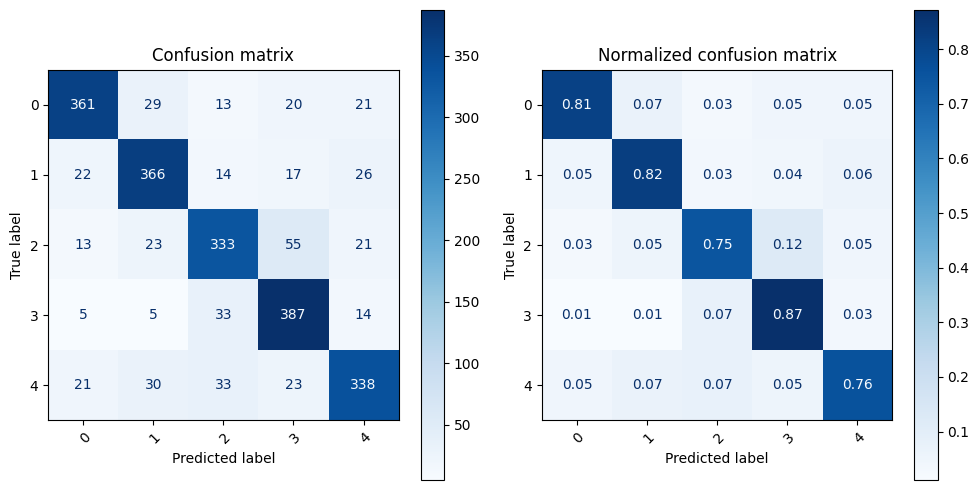

In [19]:
get_evaluation(y_test, prediction, proba)

In [20]:
from sklearn.metrics import classification_report

print(classification_report(y_test, prediction))

              precision    recall  f1-score   support

           0       0.86      0.81      0.83       444
           1       0.81      0.82      0.82       445
           2       0.78      0.75      0.76       445
           3       0.77      0.87      0.82       444
           4       0.80      0.76      0.78       445

    accuracy                           0.80      2223
   macro avg       0.80      0.80      0.80      2223
weighted avg       0.80      0.80      0.80      2223



In [22]:
import joblib

joblib.dump(m_nb_pipe, 'feeling_model.pkl')

['feeling_model.pkl']

In [23]:
joblib.dump(f_encoder, 'encoder_feeling.pkl')

['encoder_feeling.pkl']